

# Project: Investigate a Dataset - No-Show Medical Appointment

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction


### Dataset Description 
Dataset Description
This dataset contains medical appointment records in Brazil, showing whether patients showed up or missed their scheduled appointments. It includes one table with the following columns:

PatientId, AppointmentID, Gender, ScheduledDay, AppointmentDay, Age, Neighbourhood, Scholarship, Hipertension, Diabetes, Alcoholism, Handcap, SMS_received, No-show



### Question(s) for Analysis
Main Question:
What factors are associated with patients missing their medical appointments?

Sub-questions:
What factors affect patient appointment attendance?

Independent variables to explore:

1. MS_received – Does receiving an SMS reminder affect appointment attendance or no-show?

2. Gender – Is there a difference between males and females in attending or missing appointments?

3. age /alcoholism - Is there a relationship between age, alcoholism, and missing appointments?

4. ScheduledDay / AppointmentDay – Is there a relationship between the time gap from ScheduledDay to AppointmentDay and patients’ attendance or no-show?





In [3]:
# Importing libraries

import numpy as np
import pandas as pd

#Show visuals inline
import matplotlib.pyplot as plt


<a id='wrangling'></a>
## Data Wrangling






In [4]:
# Load the dataset
df = pd.read_csv('Database_No_show_appointments/noshowappointments-may-2016.csv')
# Explore the structure and content of the dataset
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [5]:
df.shape # att 14

(110527, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [7]:
df['Neighbourhood'].unique()

array(['JARDIM DA PENHA', 'MATA DA PRAIA', 'PONTAL DE CAMBURI',
       'REPÚBLICA', 'GOIABEIRAS', 'ANDORINHAS', 'CONQUISTA',
       'NOVA PALESTINA', 'DA PENHA', 'TABUAZEIRO', 'BENTO FERREIRA',
       'SÃO PEDRO', 'SANTA MARTHA', 'SÃO CRISTÓVÃO', 'MARUÍPE',
       'GRANDE VITÓRIA', 'SÃO BENEDITO', 'ILHA DAS CAIEIRAS',
       'SANTO ANDRÉ', 'SOLON BORGES', 'BONFIM', 'JARDIM CAMBURI',
       'MARIA ORTIZ', 'JABOUR', 'ANTÔNIO HONÓRIO', 'RESISTÊNCIA',
       'ILHA DE SANTA MARIA', 'JUCUTUQUARA', 'MONTE BELO',
       'MÁRIO CYPRESTE', 'SANTO ANTÔNIO', 'BELA VISTA', 'PRAIA DO SUÁ',
       'SANTA HELENA', 'ITARARÉ', 'INHANGUETÁ', 'UNIVERSITÁRIO',
       'SÃO JOSÉ', 'REDENÇÃO', 'SANTA CLARA', 'CENTRO', 'PARQUE MOSCOSO',
       'DO MOSCOSO', 'SANTOS DUMONT', 'CARATOÍRA', 'ARIOVALDO FAVALESSA',
       'ILHA DO FRADE', 'GURIGICA', 'JOANA D´ARC', 'CONSOLAÇÃO',
       'PRAIA DO CANTO', 'BOA VISTA', 'MORADA DE CAMBURI', 'SANTA LUÍZA',
       'SANTA LÚCIA', 'BARRO VERMELHO', 'ESTRELINHA', 'FORTE SÃO 

In [8]:
df['SMS_received'].unique()

array([0, 1])

In [9]:
# Not sure if 'Handcap' indicates the severity or the number of disabilities.
#df['Handcap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0)
#df['Has_Handicap'] = (df['Handcap'] > 0).astype(int)
df['Handcap'].unique()


array([0, 1, 2, 3, 4])

In [10]:
df['Age'].unique()# outlier -1

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99,  -1])

In [11]:
#Older ages are expected in hospital data and not outliers despite being rare
df[df['Age'] > 100]['Age'].value_counts()

115    5
102    2
Name: Age, dtype: int64

In [12]:
df['No-show'].value_counts()

No     88208
Yes    22319
Name: No-show, dtype: int64

In [13]:
df.duplicated().sum()

0


### Data Cleaning
**Data Cleaning Steps:**

- Convert **PatientId** from `float64` to `integer` type.  
- Convert **ScheduledDay** and **AppointmentDay** from `object` (string) to `datetime` format
- Remove rows where **Age** has negative values
- Not sure if **'Handcap'** indicates the severity or the number of disabilities
- No missing values or duplicate rows found in the dataset
 

In [14]:
# Convert PatientId to integer to remove scientific notation and treat IDs as whole numbers
df['PatientId'] = df['PatientId'].astype('int64')

In [15]:
# Convert date columns from string to datetime format for easier time-based analysis
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']) 

In [16]:
# Dropping outliers -1
df.drop(df[df['Age'] < 0].index, inplace=True)

In [17]:
# Check the updated data types and row count after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  int64              
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  object             
 3   ScheduledDay    110526 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110526 non-null  datetime64[ns, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  object             
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show       

In [18]:
# Check unique ages to confirm that invalid value
df['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99])

<a id='eda'></a>
## Exploratory Data Analysis





In [20]:
#This function calculates count, mean, or full descriptive statistics for a column after grouping by specified columns
def groupby_stats(df, group_cols, target_col, agg='mean'):
    if agg == 'mean':
        return df.groupby(group_cols)[target_col].mean()
    elif agg == 'value_counts':
        return df.groupby(group_cols)[target_col].value_counts()
    elif agg == 'describe':
        return df.groupby(group_cols)[target_col].describe()
    else:
        raise ValueError("Aggregation method not supported")


### Research Question 1 (Does receiving an SMS reminder affect appointment attendance or no-show?)

In [21]:
groupby_stats(df, ['No-show'], 'SMS_received', agg='mean')


No-show
No     0.291337
Yes    0.438371
Name: SMS_received, dtype: float64

In [22]:
groupby_stats(df, ['No-show'], 'SMS_received', agg='value_counts')


No-show  SMS_received
No       0               62509
         1               25698
Yes      0               12535
         1                9784
Name: SMS_received, dtype: int64

In [23]:
no_sms_rate = (df[df['SMS_received'] == 0]['No-show'] == 'Yes').mean() * 100
no_sms_rate

16.703533926762965

In [24]:
yes_sms_rate = (df[df['SMS_received'] == 1]['No-show'] == 'Yes').mean() * 100
yes_sms_rate 


27.574544839637

In [25]:
no_sms_rate1 = (df[df['SMS_received'] == 0]['No-show'] == 'No').mean() * 100
no_sms_rate1

83.29646607323703

In [26]:
yes_sms_rate2 = (df[df['SMS_received'] == 1]['No-show'] == 'No').mean() * 100
yes_sms_rate2

72.425455160363

In [43]:
#Bar chart showing the effect of SMS on patient no-show rate
def plot_sms_effect(no_sms_rate, yes_sms_rate, title, colors):
    pd.DataFrame({
        "SMS_Status": ["No SMS", "SMS Received"], 
        "No_Show_Rate": [no_sms_rate, yes_sms_rate]
    }).plot(
        kind="bar",
        x="SMS_Status",
        title=title,
        legend=False,
        xlabel="SMS Status",
        ylabel="No-Show Rate (%)",
        rot=0,
        color=colors
    )
    plt.show()

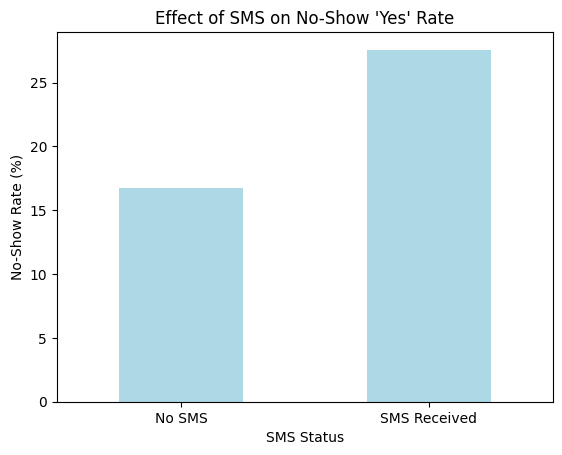

In [27]:
plot_sms_effect(
    no_sms_rate, yes_sms_rate,
    "Effect of SMS on No-Show 'Yes' Rate",
    ['lightblue', 'coral']
)

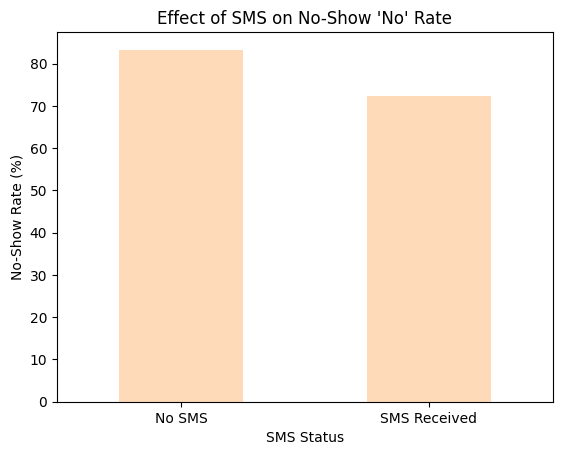

In [28]:

#They did show up
plot_sms_effect(
    no_sms_rate1, yes_sms_rate2,
    "Effect of SMS on No-Show 'No' Rate",
    ['peachpuff']
)

No-Show and Attendance Rates by SMS Reminder Status
No-show rate without SMS: 16.70%, with SMS: 27.57%; attendance rate without SMS: 83.30%, with SMS: 72.43%
Receiving an SMS reminder is inversely associated with appointment attendance.



### Research Question 2 - Is there a difference between males and females in attending or missing appointments?


In [33]:
gender_rates = df.groupby(['Gender', 'No-show']).size().unstack(fill_value=0)
gender_rates = gender_rates.div(gender_rates.sum(axis=1), axis=0)

In [40]:
df_gender = pd.DataFrame({
    "Gender": ["Female_Show", "Female_No_Show", "Male_Show", "Male_No_Show"],
    "No_Show_Rate": [
        gender_rates.loc['F','No'], 
        gender_rates.loc['F','Yes'], 
        gender_rates.loc['M','No'], 
        gender_rates.loc['M','Yes']
    ]
})

df_gender 


,Gender,No_Show_Rate
0,Female_Show,0.796851
1,Female_No_Show,0.203149
2,Male_Show,0.800321
3,Male_No_Show,0.199679


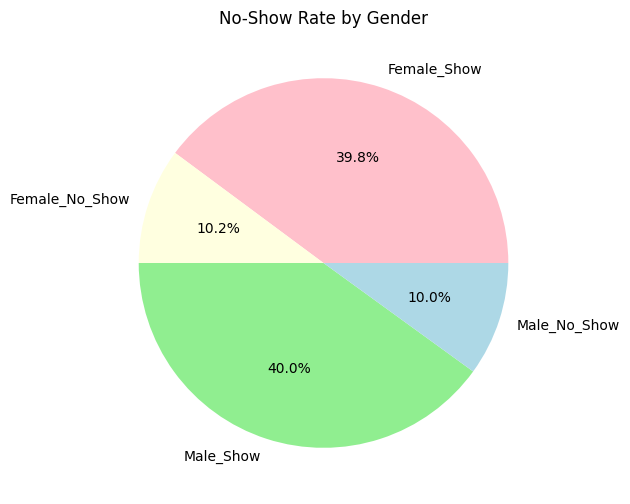

In [42]:
df_gender.plot(
    kind="pie",
    y="No_Show_Rate",
    labels=df_gender["Gender"],
    title="No-Show Rate by Gender",
    legend=False,
    autopct='%1.1f%%',
    colors=['pink','lightyellow', 'lightgreen','lightblue'],  
    figsize=(6,6)
)

plt.ylabel('')
plt.show()


The attendance rate among males is slightly higher than that of females.
Similarly, the no-show rate is slightly higher among females.
However, the difference is minimal and does not indicate a strong impact of gender on appointment attendance.


### Research Question 3 - Is there a relationship between age, alcoholism, and missing appointments?

In [78]:
df['Age'].describe()

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [79]:
df['Alcoholism'].value_counts()

0    107166
1      3360
Name: Alcoholism, dtype: int64

In [80]:
df['No-show-binary'] = (df['No-show'] == 'Yes').astype(int)

In [81]:
df[df['Alcoholism'] == 1]['No-show-binary'].mean()

0.20148809523809524

In [82]:
df[df['Alcoholism'] == 0]['No-show-binary'].mean()

0.20194837915010358

In [83]:
#I see a slight link, so I’ll group ages for deeper analysis
groupby_stats(df, ['Alcoholism', 'Age'], 'No-show-binary', agg='describe')

count      mean       std  min  25%  50%  75%  max
Alcoholism Age                                                     
0          0    3539.0  0.180559  0.384707  0.0  0.0  0.0  0.0  1.0
           1    2273.0  0.182578  0.386405  0.0  0.0  0.0  0.0  1.0
           2    1618.0  0.155748  0.362728  0.0  0.0  0.0  0.0  1.0
           3    1513.0  0.183080  0.386860  0.0  0.0  0.0  0.0  1.0
           4    1298.0  0.217257  0.412538  0.0  0.0  0.0  0.0  1.0
...                ...       ...       ...  ...  ...  ...  ...  ...
1          80      8.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
           81     16.0  0.062500  0.250000  0.0  0.0  0.0  0.0  1.0
           82      3.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
           84      1.0  0.000000       NaN  0.0  0.0  0.0  0.0  0.0
           85      1.0  0.000000       NaN  0.0  0.0  0.0  0.0  0.0

[181 rows x 8 columns]

In [84]:
def no_show_rate(df, age_min=0, age_max=115, alcoholism=None, show=True):
    query_parts = [f"Age >= {age_min}", f"Age < {age_max}"]
    if alcoholism is not None:
        query_parts.append(f"Alcoholism == {alcoholism}")
    query_str = " and ".join(query_parts)
    
    rate = df.query(query_str)['No-show-binary'].mean() * 100
    
    if show:
        print(f"Rate for Age {age_min}-{age_max}, Alcoholism={alcoholism}: {rate:.2f}%")
    
    return rate


In [85]:
df_young_yes = no_show_rate(df, age_max=18, alcoholism=1)

Rate for Age 0-18, Alcoholism=1: 50.00%


In [86]:
df_young_no  = no_show_rate(df, age_max=18, alcoholism=0)

Rate for Age 0-18, Alcoholism=0: 21.88%


In [87]:
df_middle_yes = no_show_rate(df, age_min=18, age_max=60, alcoholism=1)

Rate for Age 18-60, Alcoholism=1: 21.71%


In [88]:
df_middle_no  = no_show_rate(df, age_min=18, age_max=60, alcoholism=0)

Rate for Age 18-60, Alcoholism=0: 21.08%


In [89]:
df_old_yes = no_show_rate(df, age_min=60, alcoholism=1)

Rate for Age 60-115, Alcoholism=1: 14.06%


In [90]:
df_old_no  = no_show_rate(df, age_min=60, alcoholism=0)

Rate for Age 60-115, Alcoholism=0: 15.35%


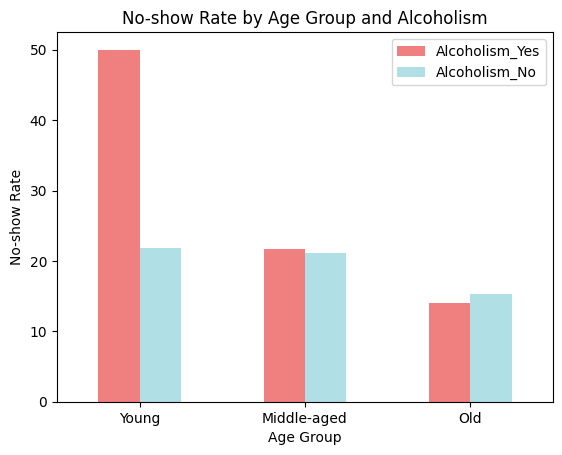

In [91]:
df_no_show = pd.DataFrame({
    "Age_Group": ['Young', 'Middle-aged', 'Old'],
    "Alcoholism_Yes": [df_young_yes, df_middle_yes, df_old_yes],
    "Alcoholism_No": [df_young_no, df_middle_no, df_old_no]
})

df_no_show.plot(
    kind='bar',
    x='Age_Group',
    title='No-show Rate by Age Group and Alcoholism',
    ylabel='No-show Rate',
    xlabel='Age Group',
    color=['lightcoral', 'powderblue'],
    rot=0
)

plt.show()

- As age increases, attendance improves
- Young people have the highest alcoholism and no-show rates (50%)
- Elderly(Old) patients are more committed to appointments (14-15%)
- Alcoholism mainly affects young patients' attendance (28% difference)
- Middle-aged patients show consistent behavior regardless of alcoholism (~21%)

### Research Question 4 – Is there a relationship between the time gap from ScheduledDay to AppointmentDay and patients’ attendance or no-show?

In [92]:
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
#df['waiting_days'] = (df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date)
df.columns


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show',
       'No-show-binary', 'waiting_days'],
      dtype='object')

In [93]:
df['waiting_days'].unique()

array([ -1,   1,   2,   0,   3,   8,  28,   9,  22,  10,  17,  16,  13,
        27,  23,  20,  14,  15,  21,  42,  29,  30,  41,  31,  55,  44,
        45,  38,  36,  37,  43,  49,  59,  51,  52,  64,  66,  90,  65,
        83,  77,  86, 114, 108,  62,  69,  71,  56,  57,  50,  58,  40,
        48,  72,  63,  19,  32,  33,   5,  34,  35,  11,  12,  39,  46,
         7,   4,   6,  24,  25,  47,  26,  18,  60,  54,  61, 175,  53,
        76,  68,  82,  75,  88,  80, 102,  78,  67,  74,  84, 111,  -2,
        79,  85,  97,  93, 141, 154, 161, 168, 103, 132, 124,  95,  87,
        89, 150, 125, 126, 110, 118,  73,  70,  81, 107, 109, 101, 121,
       100, 104,  91,  96,  92, 106,  94,  -7, 138, 131, 178, 116, 145,
       122])

In [94]:
df['waiting_days'].dtype

dtype('int64')

In [95]:
# Checked the reason for negative values: it was due to time being in 24-hour format, not 12-hour.
df[(df['waiting_days'] < 0) & (df['No-show'] == 'Yes')].head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,No-show-binary,waiting_days
145,23737169521953,5639602,M,2016-04-29 09:17:23+00:00,2016-04-29 00:00:00+00:00,17,ITARARÉ,0,0,0,0,0,0,Yes,1,-1
212,426698361512188,5642059,M,2016-04-29 14:59:38+00:00,2016-04-29 00:00:00+00:00,62,SANTOS DUMONT,0,1,1,0,0,0,Yes,1,-1
250,294272259913644,5640181,M,2016-04-29 10:13:35+00:00,2016-04-29 00:00:00+00:00,0,CARATOÍRA,0,0,0,0,0,0,Yes,1,-1
251,653745118443,5640178,F,2016-04-29 10:13:22+00:00,2016-04-29 00:00:00+00:00,33,CARATOÍRA,1,0,0,0,0,0,Yes,1,-1
440,83662492819854,5639495,F,2016-04-29 09:09:55+00:00,2016-04-29 00:00:00+00:00,25,SÃO BENEDITO,1,0,0,0,0,0,Yes,1,-1


##### Important Note:
Waiting days sometimes show negative values because of time (hours)
 I tried converting to date only (without time), but got large unexpected numbers
 So, I prefer keeping the original datetime and accept negative values
as it means patients sometimes arrive before their appointment

waiting_days = (df['AppointmentDay'] - df['ScheduledDay']).dt.days df['waiting_days'] (df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date)
df['waiting_days'].unique()

In [96]:
# Strong relationship found: Attended patients wait average 7 days vs No-show patients wait 19 day
groupby_stats(df, ['No-show'], 'waiting_days', agg='describe')

,count,mean,std,min,25%,50%,75%,max
No-show,,,,,,,,
No,88207.0,7.754759,14.550450,-1.0,-1.0,1.0,11.0,178.0
Yes,22319.0,14.831489,16.605912,-7.0,3.0,10.0,22.0,178.0


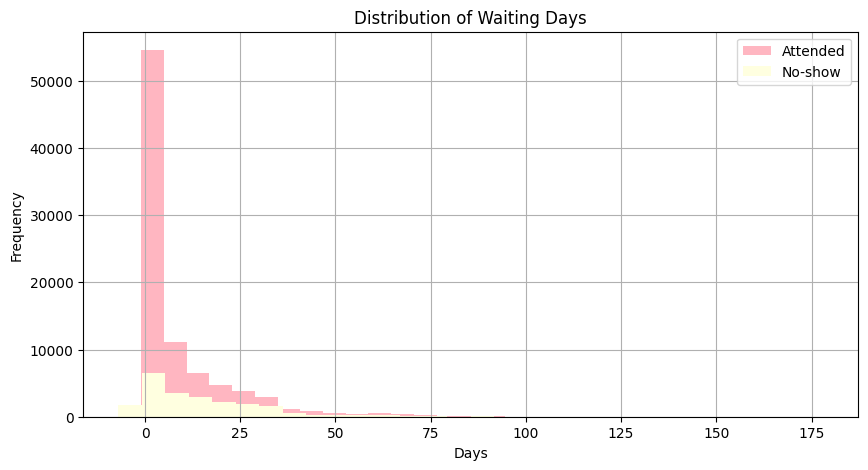

In [97]:
plt.figure(figsize=(10,5))

df[df['No-show'] == 'No']['waiting_days'].hist(
    label='Attended',
    bins=30,
    color='lightpink'
)

df[df['No-show'] == 'Yes']['waiting_days'].hist(
    label='No-show',
    bins=30,
    color='lightyellow'
)

plt.legend()
plt.title('Distribution of Waiting Days')
plt.xlabel('Days')
plt.ylabel('Frequency')

plt.show()


### As waiting time increases, no-show probability increases
- Safety Window: First 5 days (very high attendance probability)
- Risk Window: After 10 days (attendance starts to decline)
- Critical Point: 19+ days (attendance significantly decreases)

## Conclusions

Conclusions
This exploratory analysis examined patient appointment behavior across multiple dimensions to understand no-show contributing factors. We addressed both primary and subsidiary questions regarding patient attendance patterns. Four main questions and three subsidiary questions were formulated, analyzed using descriptive statistics and visualization techniques.
### Key Factors and Attendance Impact
- SMS Reminders – Patients receiving SMS had higher no-show rates (27.57%) versus those without (16.70%), indicating reminders alone may not ensure attendance. This shows that SMS reminders work as an inverse factor for supporting attendance
- Gender – No notable difference observed between male and female attendance patterns.
- Age and Alcoholism – Younger patients had the highest no-show rates, with alcoholism prevalence around 50%. Among young patients, alcoholism reduced attendance by 28%. Middle-aged patients showed consistent no-show rates (~21%) regardless of alcoholism. Elderly patients had the strongest commitment, with only 14–15% no-shows.
- Waiting Time (Scheduling-to-Appointment Gap) – Attendance peaked under 5-day waiting periods ("safety window"), declined after 10 days ("risk window"), with sharp deterioration beyond 19 days ("critical point"). Attendees averaged 7-day waits versus 19 days for no-shows.
### Limitations:
Analysis utilized descriptive statistics and visual examination without advanced statistical testing to confirm result significance. Some data categories like disabilities lacked clarity for accurate impact assessment. Unrecorded social and psychological factors may influence patient attendance patterns

In [45]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 521546 bytes to Investigate_a_Dataset.html
